# Visualization for deliveries per month
Thought showing visualizations for the number of deliveries per month might be interesting.
Could also do something to show the person receiving the most deliveries for each month?

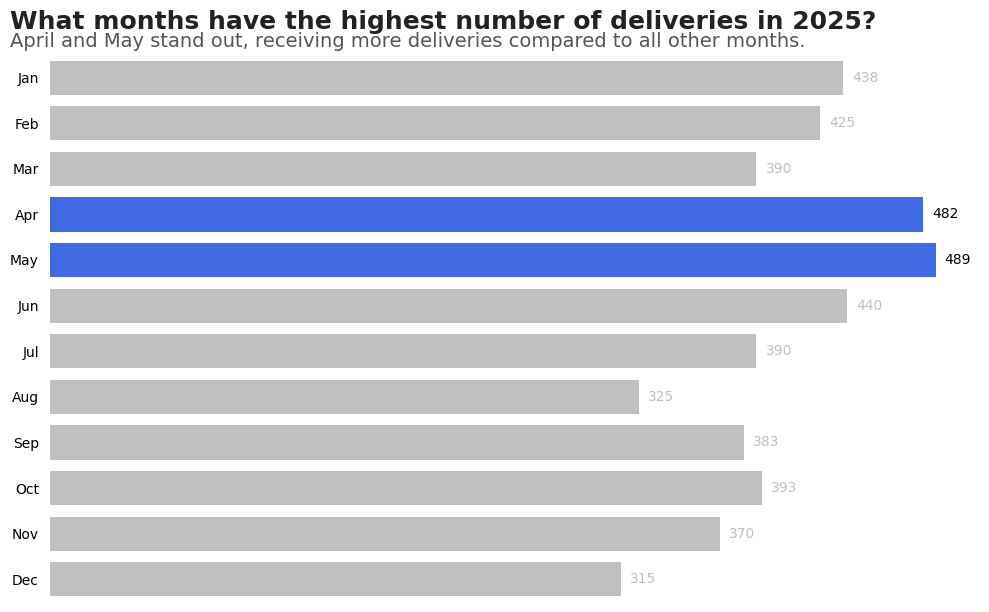

In [ ]:
import pandas as pd
from MonthEnum import Date
import matplotlib.pyplot as plt


df = pd.read_csv("../Data/PantrytoPorchData2025.csv")
df = df[["Date"]]

temp_dict = {}

for row in df.itertuples():
    date_num = int(row.Date.split("/")[0])
    cur_date = Date(date_num).name
    
    if cur_date not in temp_dict:
        temp_dict[cur_date] = 1
    
    else:
        temp_dict[cur_date] += 1

month_deliveries = pd.DataFrame.from_dict(temp_dict, orient='index', columns=['Total Deliveries'])
month_deliveries.index.name = 'Month'
month_deliveries = month_deliveries.reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
target_months = ["Apr", "May"]
for row in month_deliveries.itertuples():
    cur_month = row[1]
    num_deliveries = row[2]
    if cur_month in target_months:
        ax.barh(cur_month, num_deliveries, color = "royalblue", height = 0.75)
        ax.text(num_deliveries + 5, row.Index, num_deliveries, va="center")
    else:
        ax.barh(cur_month, num_deliveries, color = "silver", height = 0.75)
        ax.text(num_deliveries + 5, row.Index, num_deliveries, va="center", color = "silver")

ax.invert_yaxis()
ax.spines[["left", "top", "right", "bottom"]].set_visible(False)
ax.tick_params("both", length = 0, labelsize = 10, pad = 8)
ax.set_xticklabels([])
ax.set_ylim(11.5, -1) # I don't know why its -1. I was trying to remove the extra white space at the bottom.


main = "What months have the highest number of deliveries in 2025?"
sub = "April and May stand out, receiving more deliveries compared to all other months."
fig.text(0.015, 0.98, main, ha="left", fontsize=18, color="#222222", weight="bold") # Main
fig.text(0.015, 0.95, sub, ha="left", fontsize=14, color="#555555") # Sub

plt.tight_layout()
plt.show()